In [1]:
# Importations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Styling
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Chargement des données

path = "/content/drive/MyDrive/Mall_Customers.csv"

df = pd.read_csv(path)

In [4]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


# Compréhension des données

In [6]:
# structure générale du dataset
df.shape

(200, 5)

In [7]:
# les noms de colonnes (variables / features)
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
# statistique des variables numerique
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# nombre de valeurs manquante

df.isna().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [11]:
# nombre de lignes dupliquées

df.duplicated().sum()

np.int64(0)

In [14]:
# Identifier les variables (features) + Types (numériques / catégorielles)

# colonnes numériques
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# colonnes catégorielles
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Affichage
print("Variables numériques :", num_cols)

print("Variables catégorielles :", cat_cols)

Variables numériques : ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Variables catégorielles : ['Genre']


In [17]:
# Numériques : discrètes vs continues
# peu de valeurs uniques => plutôt discrète

discrete = []
continuous = []

for c in num_cols:
    # nombre de valeurs différentes dans la colonne
    n_unique = df[c].nunique()

    # si <= 15 valeurs uniques => discrète
    if n_unique <= 15:
        discrete.append(c)
    else:
        continuous.append(c)

print("Numériques discrètes :", discrete)
print("Numériques continues :", continuous)

# nombre de valeurs unique par variable numérique
df[num_cols].nunique().sort_values()

Numériques discrètes : []
Numériques continues : ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,0
Age,51
Annual Income (k$),64
Spending Score (1-100),84
CustomerID,200


In [20]:
# Catégorielles : nominales vs ordinales

# On imprime les colonnes catégorielles + leurs valeurs pour décider.
for c in cat_cols:
    uniques = df[c].unique()
    print(f"{c} -> {uniques}")

print("'Gender' est nominal pas d'ordre")

Genre -> ['Male' 'Female']
'Gender' est nominal pas d'ordre


In [22]:
# Statistiques descriptives (moyenne, variance, etc.)

stats = df[num_cols].agg(["count", "mean", "median", "var", "std", "min", "max"]).T

# skewness : voir si la distribution est pencher (gauche/droite)
stats["skew"] = df[num_cols].skew(numeric_only=True)

# kurtosis : voir si la distribution est plus/moins pointue que la normale
stats["kurtosis"] = df[num_cols].kurtosis(numeric_only=True)

# Affichage
stats

,count,mean,median,var,std,min,max,skew,kurtosis
CustomerID,200.0,100.50,100.5,3350.000000,57.879185,1.0,200.0,0.000000,-1.200000
Age,200.0,38.85,36.0,195.133166,13.969007,18.0,70.0,0.485569,-0.671573
Annual Income (k$),200.0,60.56,61.5,689.835578,26.264721,15.0,137.0,0.321843,-0.098487
Spending Score (1-100),200.0,50.20,50.0,666.854271,25.823522,1.0,99.0,-0.047220,-0.826629


<Figure size 1200x800 with 0 Axes>

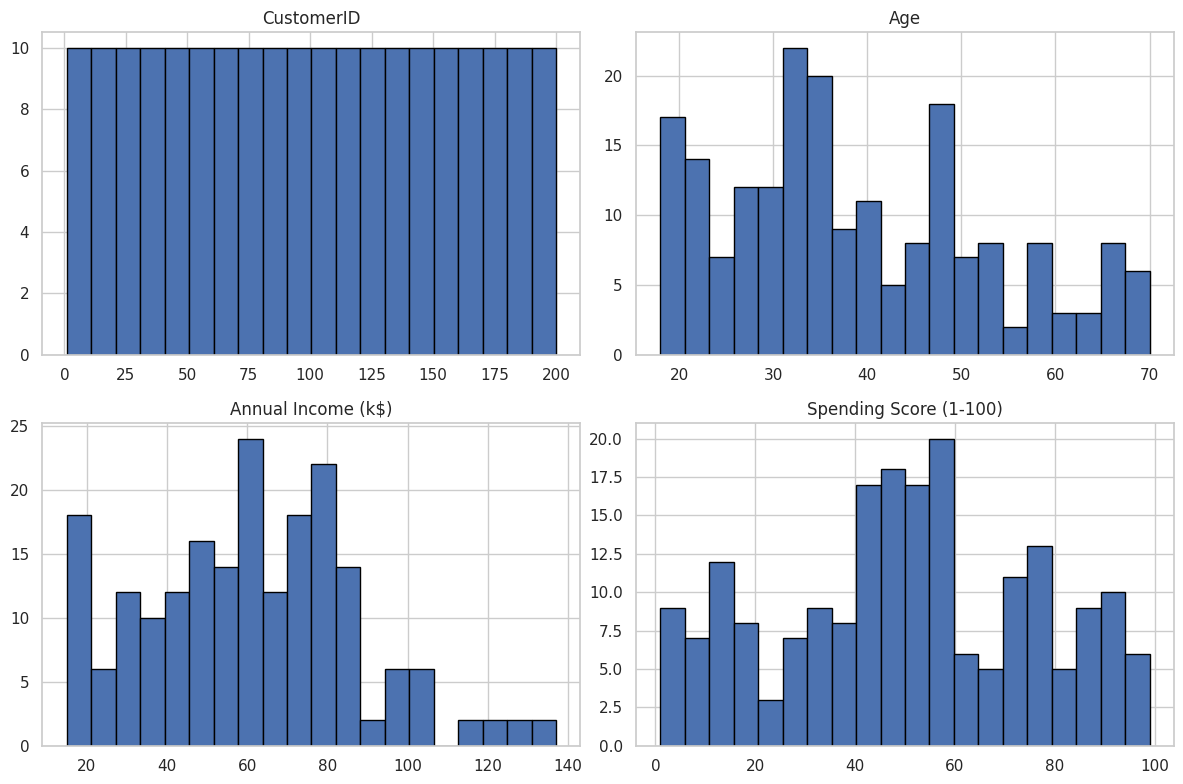

In [23]:
# Visualisations : Histogrammes (distribution des variables numériques)

plt.figure(figsize=(12, 8))
df[num_cols].hist(bins=20, figsize=(12, 8), edgecolor="black")
plt.tight_layout()
plt.show()

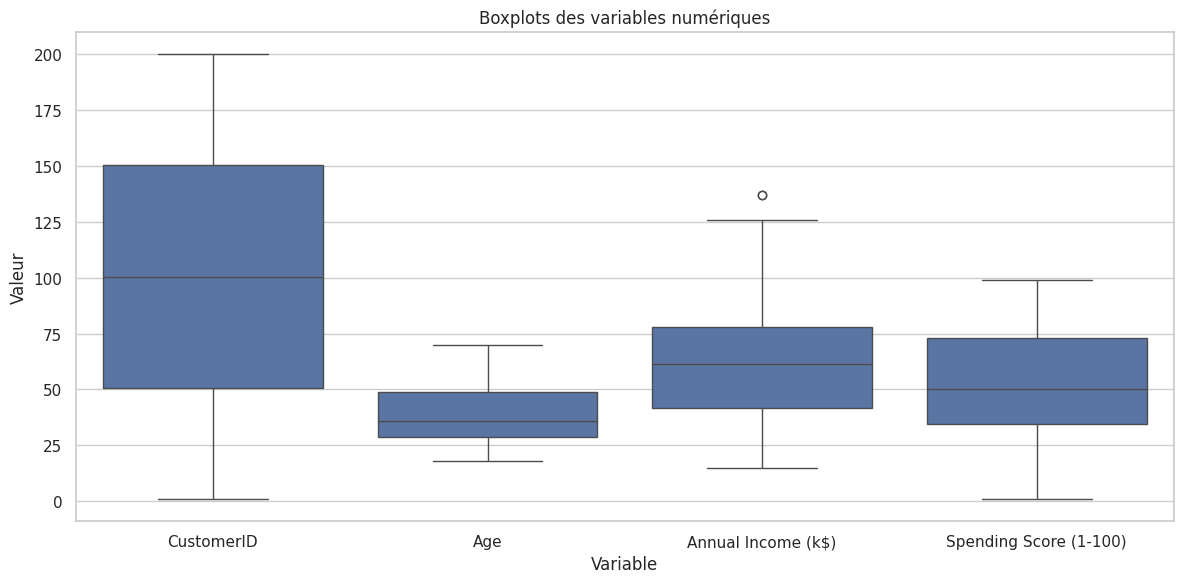

In [27]:
# Visualisations : Boxplots (détection des valeurs extrêmes / outliers)

plt.figure(figsize=(12, 6))
df_long = df[num_cols].melt(var_name="Variable", value_name="Valeur")
sns.boxplot(data=df_long, x="Variable", y="Valeur")
plt.title("Boxplots des variables numériques")
plt.tight_layout()
plt.show()

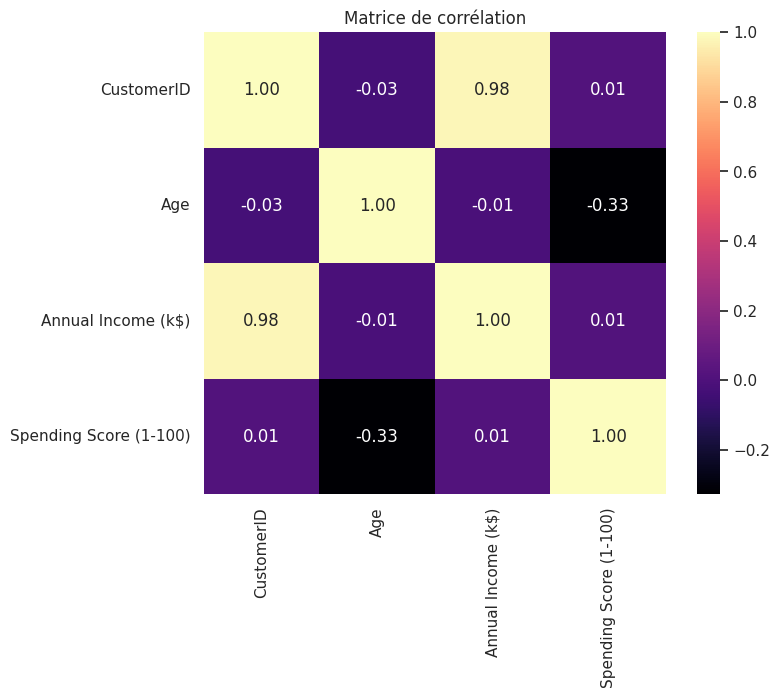

In [30]:
# Matrice de corrélation

corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="magma", fmt=".2f", square=True)
plt.title("Matrice de corrélation")
plt.show()

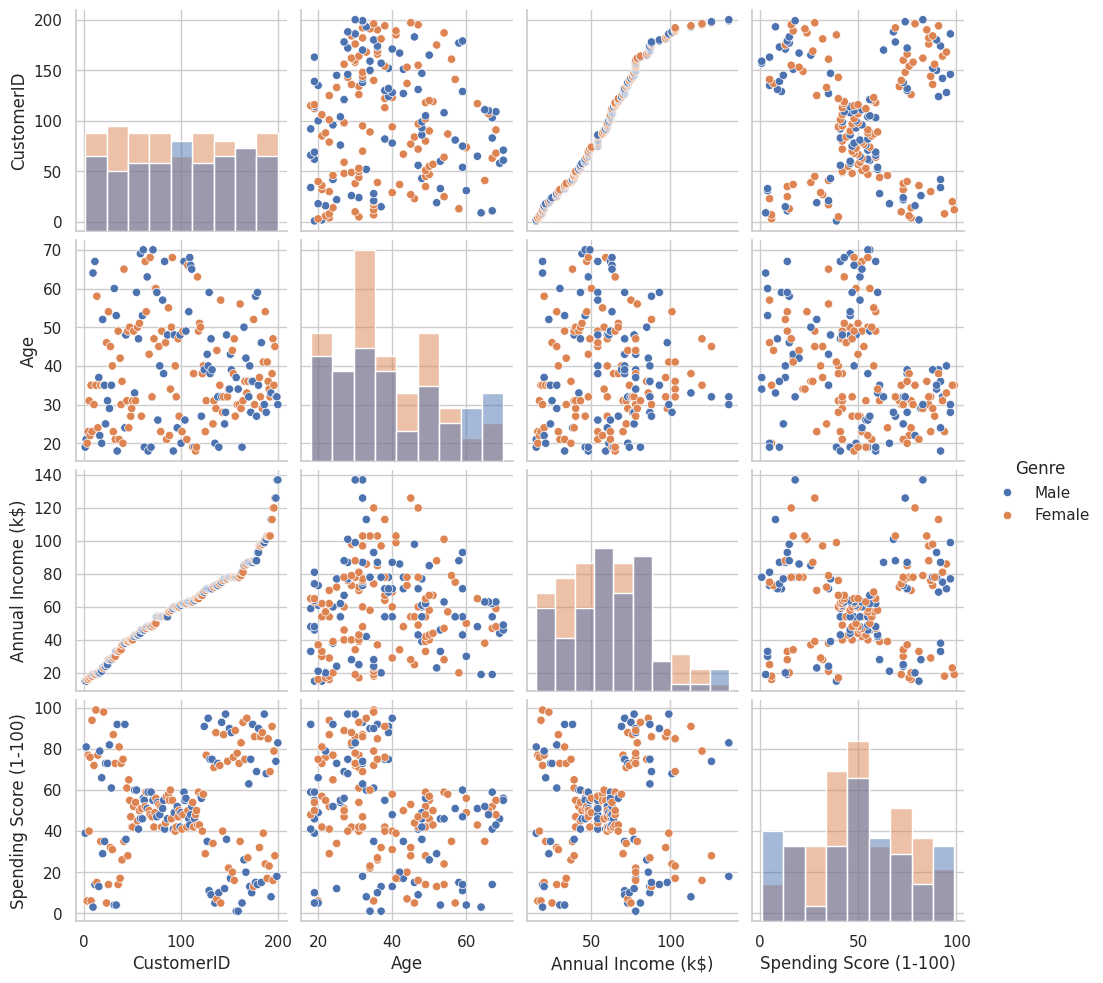

In [32]:
# Scatter plots : relations entre variables

sns.pairplot(df, vars=num_cols, hue=cat_cols[0] if len(cat_cols) > 0 else None, diag_kind="hist")

plt.show()

# Prétraitement des données

In [36]:
# Encodage de la seul variable catégorielle "Genre" (One-Hot Encoding)
df["Genre"].value_counts()

df_encoded = pd.get_dummies(df, columns=["Genre"], drop_first=True)
df_encoded.head()


df_encoded.columns
df_encoded.filter(like="Genre").head()

,Genre_Male
0,True
1,True
2,False
3,False
4,False


In [37]:
# Standardisation
from sklearn.preprocessing import StandardScaler

cols_to_drop = [c for c in ["CustomerID"] if "df_encoded" in globals() and c in df_encoded.columns]
if "X" not in globals():
    X = df_encoded.drop(columns=cols_to_drop)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)    # apprend mean/std puis transforme X
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)  # reconvertit en DataFrame
X_scaled.head() # affichage

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


In [38]:
# Traitement des valeurs aberrantes (outliers)

if "X" not in globals():
    X = df.select_dtypes(include=["int64", "float64"]).copy()

# 1) Méthode Z-score (une valeur est aberrante si elle est trop loin de la moyenne en nombre d'écarts-types)

z_thresh = 3
z_scores = (X - X.mean()) / X.std(ddof=0)
outliers_z_mask = (np.abs(z_scores) > z_thresh).any(axis=1)

print("Z-score -> nombre de lignes outliers :", outliers_z_mask.sum())

X_no_outliers_z = X.loc[~outliers_z_mask].copy()



Z-score -> nombre de lignes outliers : 0


In [41]:
# 2) Méthode IQR
# on utilise l'intervalle interquartile (Q3 - Q1) Outlier si < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR

X_num = X.select_dtypes(include=[np.number]).copy()
X_num = X_num.loc[:, X_num.dtypes != bool]

Q1 = X_num.quantile(0.25)
Q3 = X_num.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr_mask = ((X_num < lower_bound) | (X_num > upper_bound)).any(axis=1)

print("IQR -> nombre de lignes outliers :", outliers_iqr_mask.sum())

X_no_outliers_iqr = X.loc[~outliers_iqr_mask].copy()


IQR -> nombre de lignes outliers : 2


In [40]:
# 3) Isolation Forest
#  modèle qui "isole" les points rares (anomalies) via des arbres

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Fit + prédiction : 1 = normal, -1 = anomalie
iso_labels = iso.fit_predict(X)

outliers_iso_mask = (iso_labels == -1)

print("Isolation Forest -> nombre de lignes outliers :", outliers_iso_mask.sum())

X_no_outliers_iso = X.loc[~outliers_iso_mask].copy()


Isolation Forest -> nombre de lignes outliers : 10


In [42]:
# Résumé

print("\nTaille originale :", X.shape)
print("Sans outliers (Z-score)         :", X_no_outliers_z.shape)
print("Sans outliers (IQR)             :", X_no_outliers_iqr.shape)
print("Sans outliers (IsolationForest) :", X_no_outliers_iso.shape)


Taille originale : (200, 4)
Sans outliers (Z-score)         : (200, 4)
Sans outliers (IQR)             : (198, 4)
Sans outliers (IsolationForest) : (190, 4)


# Modèles à implémenter

In [49]:
#Clustering (regroupement)
# K-Means Clustering
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")  # crée le modèle
labels_kmeans = kmeans.fit_predict(X_scaled)                   # entraîne + donne le cluster de chaque ligne

labels_kmeans[:10]  # aperçu des 10 premiers labels

array([2, 2, 4, 4, 4, 4, 4, 4, 0, 4], dtype=int32)

In [46]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN

# eps = rayon du voisinage, min_samples = nb minimum de points pour former un cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

labels_dbscan[:10]

array([-1, -1, -1,  0, -1,  0, -1, -1, -1,  0])

In [47]:
# Agglomerative Clustering (Hiérarchique)
from sklearn.cluster import AgglomerativeClustering

# n_clusters = nombre final de groupes
agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

labels_agg[:10]

array([0, 0, 3, 0, 3, 0, 3, 0, 4, 0])

In [48]:
# Gaussian Mixture Models (GMM)
from sklearn.mixture import GaussianMixture

# n_components = nombre de clusters
gmm = GaussianMixture(n_components=5, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

labels_gmm[:10]

array([2, 2, 4, 4, 4, 4, 4, 4, 0, 4])

In [50]:
#Réduction de dimension
# PCA (Principal Component Analysis)
from sklearn.decomposition import PCA

# On réduit à 2 composantes pour visualiser
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum()

(array([0.33690046, 0.26230645]), np.float64(0.5992069019819846))

In [51]:
# t-SNE (visualisation)
from sklearn.manifold import TSNE

# t-SNE pour visualiser
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

X_tsne[:5]

array([[ 2.4259703, -7.152119 ],
       [ 3.0424936, -5.47838  ],
       [-4.405653 , 14.091286 ],
       [-7.8193455, 12.497788 ],
       [-4.6307945, 12.384195 ]], dtype=float32)

In [52]:
# UMAP (option avancée)

# Installer umap-learn
!pip -q install umap-learn
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

X_umap[:5]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


array([[13.292794 ,  5.3179836],
       [12.983909 ,  5.4274373],
       [-1.889931 ,  9.602773 ],
       [-3.3003285, 11.730886 ],
       [-1.8459321,  9.789315 ]], dtype=float32)

Colonnes disponibles : ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


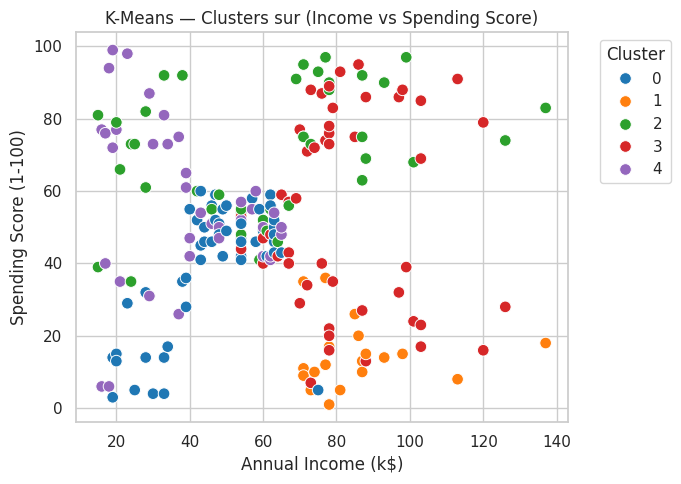

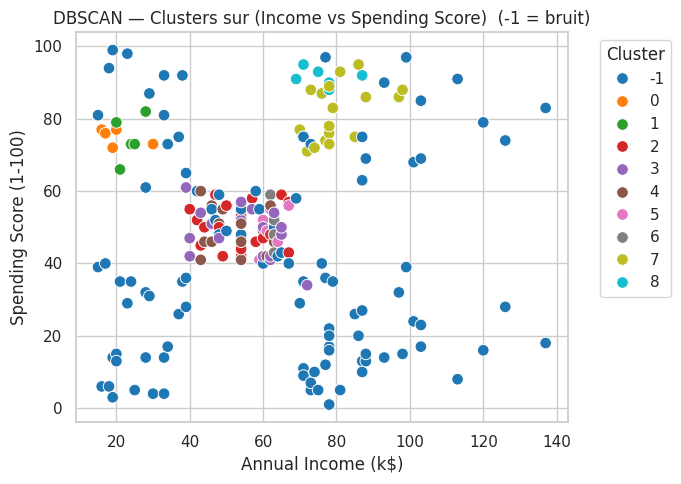

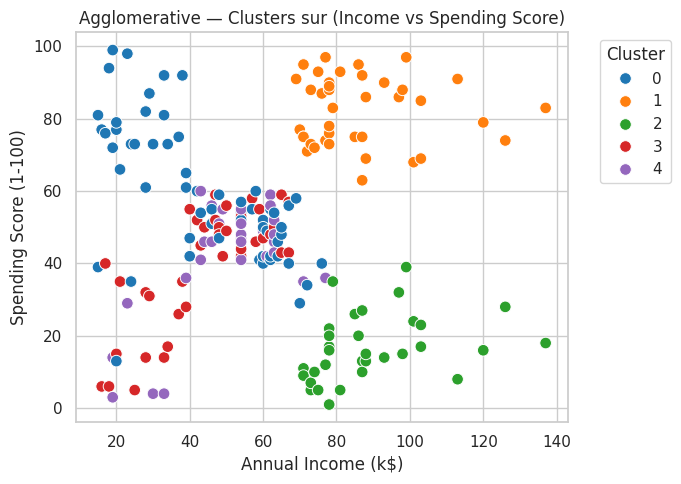

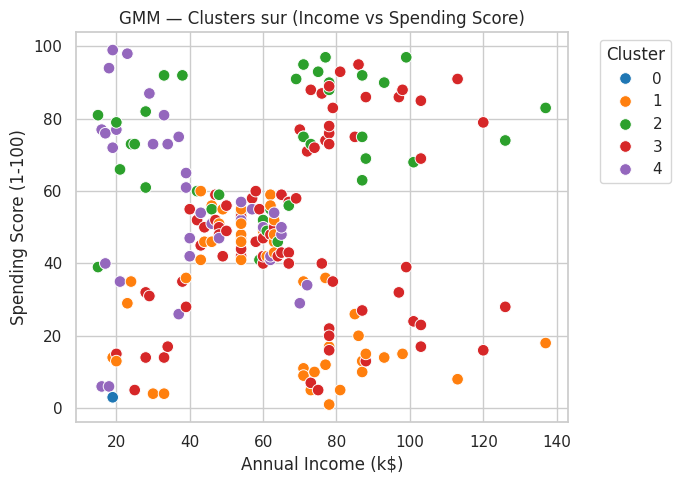

In [60]:
# Visualisation des clusters

# Choix de 2 variables pour visualiser
x_col = "Annual Income (k$)"
y_col = "Spending Score (1-100)"

# Petite vérification
print("Colonnes disponibles :", df.columns.tolist())

# Fonction pour afficher un modèle
def plot_model_on_features(labels, title):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x=x_col, y=y_col,
        hue=labels,
        palette="tab10",
        s=70
    )
    plt.title(title)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# K-Means
if "labels_kmeans" in globals():
    plot_model_on_features(labels_kmeans, "K-Means — Clusters sur (Income vs Spending Score)")

# DBSCAN
if "labels_dbscan" in globals():
    plot_model_on_features(labels_dbscan, "DBSCAN — Clusters sur (Income vs Spending Score)  (-1 = bruit)")

# Agglomerative
if "labels_agg" in globals():
    plot_model_on_features(labels_agg, "Agglomerative — Clusters sur (Income vs Spending Score)")

# GMM
if "labels_gmm" in globals():
    plot_model_on_features(labels_gmm, "GMM — Clusters sur (Income vs Spending Score)")

# Évaluation des modèles

In [53]:
# Évaluation interne du clustering (sans variable cible)
# Métriques : Silhouette, Davies-Bouldin, Calinski-Harabasz
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels, model_name="Model"):
    # Retire le bruit (-1) si présent (cas DBSCAN)
    mask = labels != -1
    X_eval = X[mask] if hasattr(X, "__getitem__") else X
    labels_eval = labels[mask]

    # Si on a moins de 2 clusters, les métriques ne sont pas calculables
    n_clusters = len(np.unique(labels_eval))
    if n_clusters < 2:
        return {
            "model": model_name,
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    return {
        "model": model_name,
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval)
    }

results = []

# Évalue K-Means si labels_kmeans existe
if "labels_kmeans" in globals():
    results.append(evaluate_clustering(X_scaled.values if hasattr(X_scaled, "values") else X_scaled, labels_kmeans, "K-Means"))

# Évalue DBSCAN si labels_dbscan existe
if "labels_dbscan" in globals():
    results.append(evaluate_clustering(X_scaled.values if hasattr(X_scaled, "values") else X_scaled, labels_dbscan, "DBSCAN"))

# Évalue Agglomerative si labels_agg existe
if "labels_agg" in globals():
    results.append(evaluate_clustering(X_scaled.values if hasattr(X_scaled, "values") else X_scaled, labels_agg, "Agglomerative"))

# Évalue GMM si labels_gmm existe
if "labels_gmm" in globals():
    results.append(evaluate_clustering(X_scaled.values if hasattr(X_scaled, "values") else X_scaled, labels_gmm, "GMM"))

# Tableau des résultats
df_scores = pd.DataFrame(results)
df_scores

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,5,0.271910,1.181091,62.126342
1,DBSCAN,9,0.539519,0.630450,116.461479
2,Agglomerative,5,0.286994,1.219773,64.468707
3,GMM,5,0.221640,1.210614,45.817434


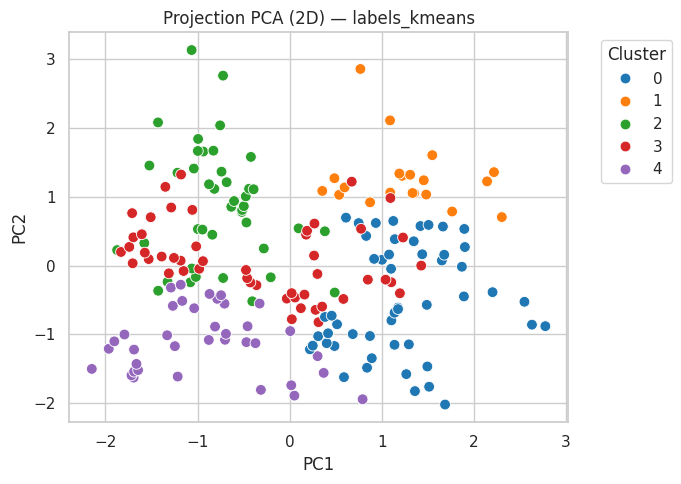

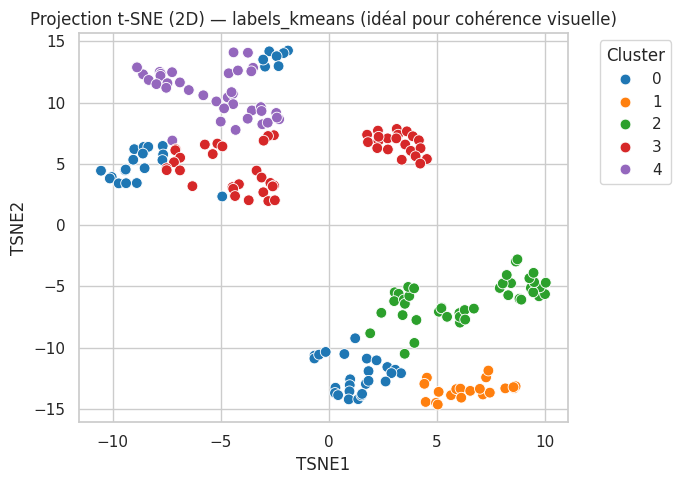

In [56]:
# Visualisation (la cohérence des clusters)
# (PCA pour structure globale) + (t-SNE pour cohérence visuelle des groupes)

sns.set(style="whitegrid")

# Choisir le modèle de clustering à visualiser
labels_name = "labels_kmeans"

# Récupère les labels depuis la variable choisie
labels = globals()[labels_name]

# Projection PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = labels

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette="tab10", s=60)
plt.title(f"Projection PCA (2D) — {labels_name}")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Projection t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
df_tsne["cluster"] = labels

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_tsne, x="TSNE1", y="TSNE2", hue="cluster", palette="tab10", s=60)
plt.title(f"Projection t-SNE (2D) — {labels_name} (idéal pour cohérence visuelle)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Bonus

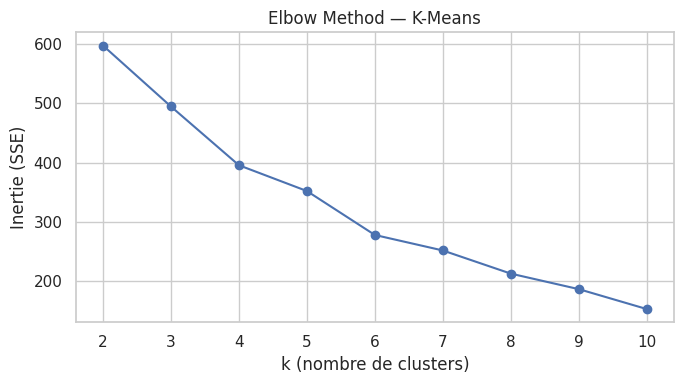

In [61]:
# Optimisation des modèles — K-Means : Elbow Method (choix de k)

k_range = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (nombre de clusters)")
plt.ylabel("Inertie (SSE)")
plt.title("Elbow Method — K-Means")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

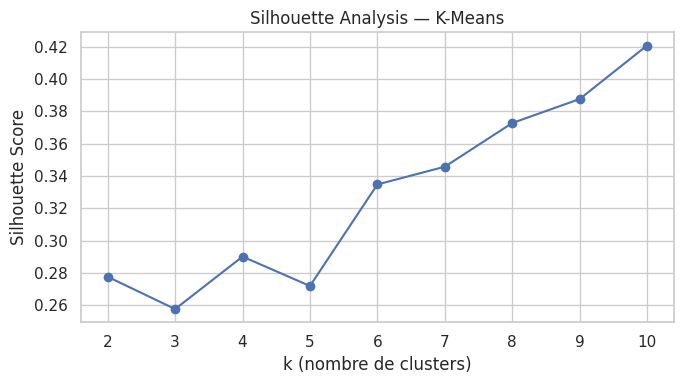

Meilleur k selon silhouette = 10


In [62]:
# Silhouette Analysis (choix de k)

k_range = range(2, 11)
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xlabel("k (nombre de clusters)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis — K-Means")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Meilleur k selon silhouette =", best_k)

In [63]:
# Entraîner K-Means avec k choisi (best_k)

k = best_k

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_kmeans = kmeans.fit_predict(X_scaled)

print("k choisi =", k)
print("Clusters (counts) :")
print(pd.Series(labels_kmeans).value_counts().sort_index())

k choisi = 10
Clusters (counts) :
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: count, dtype: int64


In [64]:
# Interprétation centroïdes K-Means (retour à l'échelle originale)

# Centre en échelle standardisée
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled.columns)

# Retour à l’échelle originale
centroids_original = pd.DataFrame(
    scaler.inverse_transform(centroids_scaled),
    columns=X_scaled.columns
)

centroids_original.index.name = "cluster"
centroids_original

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
cluster,,,,
0,58.846154,48.692308,39.846154,1.000000e+00
1,25.250000,41.250000,60.916667,1.000000e+00
2,41.214286,26.071429,20.142857,7.142857e-02
3,32.190476,86.047619,81.666667,-5.551115e-17
4,54.153846,54.230769,48.961538,0.000000e+00
5,38.473684,85.894737,14.210526,1.000000e+00
6,27.960000,57.360000,47.120000,0.000000e+00
7,33.277778,87.111111,82.666667,1.000000e+00
8,25.461538,25.692308,80.538462,-1.665335e-16


In [65]:
# Profils par cluster

# tableau avec les variables originales + le label cluster
df_clusters = X.copy()
df_clusters["cluster"] = labels_kmeans

# Moyennes par cluster (profil)
cluster_means = df_clusters.groupby("cluster").mean(numeric_only=True)
cluster_means

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
cluster,,,,
0,58.846154,48.692308,39.846154,1.000000
1,25.250000,41.250000,60.916667,1.000000
2,41.214286,26.071429,20.142857,0.071429
3,32.190476,86.047619,81.666667,0.000000
4,54.153846,54.230769,48.961538,0.000000
5,38.473684,85.894737,14.210526,1.000000
6,27.960000,57.360000,47.120000,0.000000
7,33.277778,87.111111,82.666667,1.000000
8,25.461538,25.692308,80.538462,0.000000


In [66]:
# Interprétation — PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée par PC1 et PC2 :", pca.explained_variance_ratio_)
print("Variance expliquée totale (PC1+PC2) :", pca.explained_variance_ratio_.sum())

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=["PC1_loading", "PC2_loading"]
)

# Importance (valeur absolue) pour classer les variables les plus influentes
loadings["PC1_importance"] = loadings["PC1_loading"].abs()
loadings["PC2_importance"] = loadings["PC2_loading"].abs()

# Top variables qui expliquent PC1 et PC2
print("\nTop variables PC1 :")
display(loadings.sort_values("PC1_importance", ascending=False).head(10))

print("\nTop variables PC2 :")
display(loadings.sort_values("PC2_importance", ascending=False).head(10))

Variance expliquée par PC1 et PC2 : [0.33690046 0.26230645]
Variance expliquée totale (PC1+PC2) : 0.5992069019819846

Top variables PC1 :


,PC1_loading,PC2_loading,PC1_importance,PC2_importance
Age,0.687900,-0.103690,0.687900,0.103690
Spending Score (1-100),-0.686920,0.103211,0.686920,0.103211
Genre_Male,0.234302,0.626886,0.234302,0.626886
Annual Income (k$),-0.006082,0.765252,0.006082,0.765252



Top variables PC2 :


,PC1_loading,PC2_loading,PC1_importance,PC2_importance
Annual Income (k$),-0.006082,0.765252,0.006082,0.765252
Genre_Male,0.234302,0.626886,0.234302,0.626886
Age,0.687900,-0.103690,0.687900,0.103690
Spending Score (1-100),-0.686920,0.103211,0.686920,0.103211


In [67]:
# Robustesse : sensibilité aux outliers (Isolation Forest)

# K-Means sur toutes les données
k = best_k
km_all = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_all = km_all.fit_predict(X_scaled)

scores_all = {
    "dataset": "All data",
    "n_samples": X_scaled.shape[0],
    "silhouette": silhouette_score(X_scaled, labels_all),
    "davies_bouldin": davies_bouldin_score(X_scaled, labels_all),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_all),
}

# Détection outliers : Isolation Forest
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(X_scaled)         # 1 normal, -1 outlier
mask_inliers = (iso_labels == 1)

X_inliers = X_scaled[mask_inliers]

# K-Means sur inliers seulement
km_in = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_in = km_in.fit_predict(X_inliers)

scores_in = {
    "dataset": "After IsolationForest (inliers)",
    "n_samples": X_inliers.shape[0],
    "silhouette": silhouette_score(X_inliers, labels_in),
    "davies_bouldin": davies_bouldin_score(X_inliers, labels_in),
    "calinski_harabasz": calinski_harabasz_score(X_inliers, labels_in),
}

pd.DataFrame([scores_all, scores_in])

,dataset,n_samples,silhouette,davies_bouldin,calinski_harabasz
0,All data,200,0.420764,0.833103,89.978196
1,After IsolationForest (inliers),190,0.405622,0.883038,83.402278


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


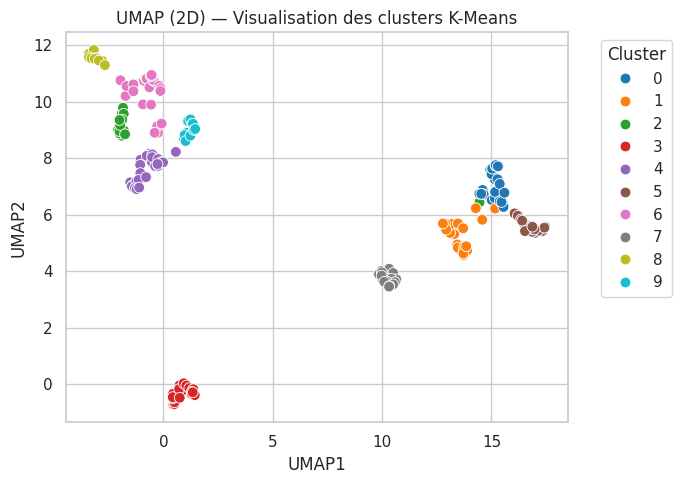

In [68]:
# Visualisation avancée : UMAP 2D + clusters K-Means

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["cluster"] = labels_kmeans

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="cluster", palette="tab10", s=60)
plt.title("UMAP (2D) — Visualisation des clusters K-Means")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()